## Introduction: From Manual Loops to Automated Search

In the previous notebook on **Cross-Validation Fundamentals**, we learned how to use `cross_val_score` to evaluate different polynomial degrees by writing a manual loop:

```python
for degree in range(1, 11):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    scores = cross_val_score(model, X_train, y_train, cv=5)
    # Store and compare scores...
```

While this approach works, it has limitations:
- **Manual iteration** through hyperparameters is tedious
- **Multiple hyperparameters** require nested loops
- **No built-in tracking** of results
- **Difficult to parallelize** efficiently

In this notebook, we'll learn **automated hyperparameter tuning** techniques that make this process much more efficient and scalable.

### Learning Objectives

By the end of this notebook, you will be able to:
1. Use `GridSearchCV` to automate exhaustive hyperparameter search
2. Apply `cross_validate` for detailed evaluation across multiple metrics
3. Use `RandomizedSearchCV` as a faster alternative to grid search
4. Tune classification thresholds using specialized tools
5. Choose the right tuning strategy for different scenarios

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_validate, cross_val_predict
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.datasets import make_classification

%matplotlib inline
plt.style.use('ggplot')
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 5, 4

## Preparing the Data

We'll use the same polynomial regression example from Notebook 1 to demonstrate GridSearchCV.

In [2]:
# Generate polynomial regression data
x = np.array([i*np.pi/180 for i in range(360)])
np.random.seed(10)
y = np.sin(x) + np.random.normal(0, 0.15, len(x))

# Prepare for modeling
X = x.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 288
Test set size: 72


## GridSearchCV: Automated Exhaustive Search

`GridSearchCV` automates the process of hyperparameter tuning by:
1. **Defining a grid** of hyperparameter values to test
2. **Systematically evaluating** every combination using cross-validation
3. **Returning the best** parameters and trained model

### How GridSearchCV Works

1. **Define a Grid of Hyperparameters:**  
   Specify the hyperparameters and their possible values.
2. **Evaluate All Combinations:**  
   Test every possible combination systematically.
3. **Cross-Validation for Model Evaluation:**  
   For each combination, train and evaluate using CV.
4. **Select the Best:**  
   Choose the combination with the best validation performance.

### Example: Finding Optimal Polynomial Degree

In [3]:
# Define the pipeline
model = make_pipeline(PolynomialFeatures(), LinearRegression())

# Define the hyperparameter grid
param_grid = {'polynomialfeatures__degree': np.arange(1, 11)}

# Define cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(
    model, 
    param_grid, 
    cv=cv, 
    scoring='r2', 
    return_train_score=True, 
    verbose=1, 
    n_jobs=-1  # Use all available cores
)

# Fit the model
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('linearregression',
                                        LinearRegression())]),
             n_jobs=-1,
             param_grid={'polynomialfeatures__degree': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])},
             return_train_score=True, scoring='r2', verbose=1)

### Exploring GridSearchCV Results

GridSearchCV stores detailed results in the `cv_results_` attribute, which we can convert to a DataFrame for analysis.

In [4]:
# Convert results to DataFrame
cv_results = pd.DataFrame(grid_search.cv_results_)

# Display key columns
pd.set_option('display.float_format', '{:.6f}'.format) 
cv_results[["param_polynomialfeatures__degree", "mean_test_score", "mean_train_score", "std_test_score"]]

,param_polynomialfeatures__degree,mean_test_score,mean_train_score,std_test_score
0,1,0.572085,0.585029,0.046098
1,2,0.566630,0.585655,0.051793
2,3,0.947902,0.950554,0.006520
3,4,0.947373,0.950681,0.006329
4,5,0.956997,0.960442,0.004993
5,6,0.956598,0.960604,0.004889
6,7,0.956398,0.960669,0.004968
7,8,0.956063,0.960754,0.004480
8,9,0.955732,0.960827,0.004856
9,10,0.955043,0.960917,0.004915


### Visualizing Training vs Test Scores

Let's plot the scores to identify the optimal degree and detect overfitting.

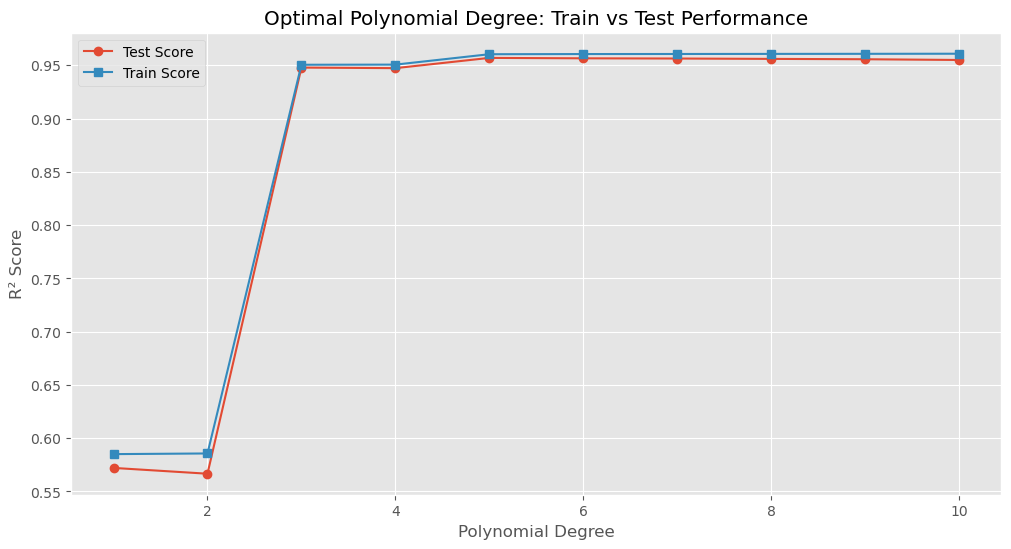

In [5]:
# Plotting cv results
plt.figure(figsize=(12, 6))

plt.plot(cv_results["param_polynomialfeatures__degree"], cv_results["mean_test_score"], 'o-', label='Test Score')
plt.plot(cv_results["param_polynomialfeatures__degree"], cv_results["mean_train_score"], 's-', label='Train Score')
plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title("Optimal Polynomial Degree: Train vs Test Performance")
plt.legend(loc='best')
plt.grid(True)
plt.show()

### Accessing the Best Results

GridSearchCV provides convenient attributes to access the best parameters and model.

In [6]:
# Print out the best hyperparameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score (R²):", grid_search.best_score_)
print("Best Estimator:", grid_search.best_estimator_)

# Evaluate on test set
test_score = grid_search.score(X_test, y_test)
print(f"\nTest Set R²: {test_score:.4f}")

Best Parameters: {'polynomialfeatures__degree': 5}
Best CV Score (R²): 0.9569966855989479
Best Estimator: Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=5)),
                ('linearregression', LinearRegression())])

Test Set R²: 0.9565


### Benefits of GridSearchCV

✅ **No manual loops**: Automates the entire search process  
✅ **Parallel processing**: Uses `n_jobs=-1` to leverage multiple CPU cores  
✅ **Comprehensive results**: Stores all scores, parameters, and timing information  
✅ **Best model ready**: `best_estimator_` is already trained and ready to use  
✅ **Guaranteed optimal**: Tests every combination in the grid  

### Limitations

⚠️ **Computationally expensive**: Exhaustive search can be slow with many hyperparameters  
⚠️ **Grid design**: Requires manual specification of parameter ranges  
⚠️ **Curse of dimensionality**: Number of combinations grows exponentially  

## Using `cross_validate` for Multiple Metrics

While `GridSearchCV` optimizes based on a single scoring metric, `cross_validate` allows you to evaluate **multiple metrics simultaneously**. This is helpful when you want to assess different aspects of model performance (e.g., R², MSE, MAE).

### Evaluating with Multiple Metrics

In [7]:
# Use the best model from GridSearchCV
best_model = grid_search.best_estimator_

# Define multiple scoring metrics
scoring = {
    'r2': 'r2',
    'neg_mse': 'neg_mean_squared_error',
    'neg_mae': 'neg_mean_absolute_error'
}

# Perform cross-validation with multiple metrics
cv_results_multi = cross_validate(
    best_model, 
    X_train, 
    y_train, 
    cv=cv, 
    scoring=scoring, 
    return_train_score=True
)

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(cv_results_multi)
print("Cross-Validation Results with Multiple Metrics:")
print(results_df)

# Print average scores
print("\nAverage Scores:")
print(f"R²: {results_df['test_r2'].mean():.4f} (±{results_df['test_r2'].std():.4f})")
print(f"MSE: {-results_df['test_neg_mse'].mean():.4f} (±{results_df['test_neg_mse'].std():.4f})")
print(f"MAE: {-results_df['test_neg_mae'].mean():.4f} (±{results_df['test_neg_mae'].std():.4f})")

Cross-Validation Results with Multiple Metrics:
   fit_time  score_time  test_r2  train_r2  test_neg_mse  train_neg_mse  \
0  0.001005    0.001999 0.958779  0.960044     -0.022048      -0.020852   
1  0.001000    0.002004 0.964405  0.958398     -0.018169      -0.021653   
2  0.000998    0.002105 0.955065  0.961197     -0.022904      -0.020553   
3  0.001037    0.001140 0.957639  0.960553     -0.022533      -0.020679   
4  0.001023    0.000998 0.949095  0.962019     -0.025200      -0.020176   

   test_neg_mae  train_neg_mae  
0     -0.120847      -0.112148  
1     -0.103464      -0.117049  
2     -0.118733      -0.114133  
3     -0.116784      -0.113619  
4     -0.126727      -0.111725  

Average Scores:
R²: 0.9570 (±0.0056)
MSE: 0.0222 (±0.0025)
MAE: 0.1173 (±0.0086)


## RandomizedSearchCV: Faster Alternative

When the hyperparameter space is large, **GridSearchCV** can become prohibitively expensive. `RandomizedSearchCV` offers a faster alternative by **randomly sampling** a specified number of parameter combinations.

### How RandomizedSearchCV Works

Instead of testing every combination, it:
1. **Randomly samples** `n_iter` combinations from the parameter distributions
2. Evaluates each using cross-validation
3. Returns the best performing combination

### When to Use RandomizedSearchCV

✅ **Large hyperparameter space**: Many parameters or continuous ranges  
✅ **Time constraints**: Need faster results  
✅ **Initial exploration**: Quick search before fine-tuning with GridSearchCV  

### Example: Random Search for Polynomial Degree

In [8]:
from scipy.stats import randint

# Define the pipeline
model_random = make_pipeline(PolynomialFeatures(), LinearRegression())

# Define parameter distributions (can use continuous or discrete distributions)
param_distributions = {
    'polynomialfeatures__degree': randint(1, 15)  # Sample from integers 1 to 14
}

# Perform Randomized Search
random_search = RandomizedSearchCV(
    model_random,
    param_distributions,
    n_iter=10,  # Number of random combinations to try
    cv=cv,
    scoring='r2',
    return_train_score=True,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Display results
print("Best Parameters (Random Search):", random_search.best_params_)
print("Best CV Score (Random Search):", random_search.best_score_)
print("\nCompare with GridSearchCV:")
print("GridSearchCV Best Score:", grid_search.best_score_)

Best Parameters (Random Search): {'polynomialfeatures__degree': 5}
Best CV Score (Random Search): 0.9569966855989479

Compare with GridSearchCV:
GridSearchCV Best Score: 0.9569966855989479


### GridSearchCV vs RandomizedSearchCV

| Aspect | GridSearchCV | RandomizedSearchCV |
|--------|-------------|-------------------|
| **Search Strategy** | Exhaustive (all combinations) | Random sampling |
| **Speed** | Slower (O(n^k) for k parameters) | Faster (O(n_iter)) |
| **Optimality** | Guaranteed best within grid | Approximate best |
| **Best For** | Small grids, fine-tuning | Large spaces, exploration |
| **Parallelization** | Yes (`n_jobs=-1`) | Yes (`n_jobs=-1`) |

**Recommendation:** Start with `RandomizedSearchCV` for quick exploration, then refine with `GridSearchCV` in a narrower range.

## Tuning Classification Thresholds

In classification problems, the default threshold is typically **0.5** (i.e., predict class 1 if probability > 0.5). However, this default may not be optimal for all problems, especially when:
- Classes are imbalanced
- Different types of errors have different costs (e.g., false positives vs false negatives)
- You want to optimize for a specific metric (F1-score, precision, recall)

Cross-validation can help find the optimal threshold.

### Generating Classification Data

In [9]:
# Generate classification dataset
X_class, y_class = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    random_state=42
)

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Train a logistic regression model
logit_model = LogisticRegression(max_iter=1000, random_state=42)
logit_model.fit(X_train_class, y_train_class)

# Default threshold (0.5) performance
y_pred_default = logit_model.predict(X_test_class)
print(f"Default threshold (0.5) accuracy: {accuracy_score(y_test_class, y_pred_default):.4f}")

Default threshold (0.5) accuracy: 0.8250


### Method 1: Using `TunedThresholdClassifierCV` (sklearn >= 1.5)

Scikit-learn provides `TunedThresholdClassifierCV` to automatically find the best threshold through cross-validation.

In [10]:
from sklearn.model_selection import TunedThresholdClassifierCV

# Define cross-validation strategy
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define TunedThresholdClassifierCV
tuned_clf = TunedThresholdClassifierCV(
    estimator=logit_model,
    scoring="f1",  # Optimize for F1-score
    cv=cv_strat
)

# Fit the model
tuned_clf.fit(X_train_class, y_train_class)

# Print the best threshold and corresponding score
print(f"Best threshold: {tuned_clf.best_threshold_:.3f}")
print(f"Best F1-score (CV): {tuned_clf.best_score_:.4f}")

# Evaluate on test set
y_pred_tuned = tuned_clf.predict(X_test_class)
from sklearn.metrics import f1_score
print(f"Test set F1-score: {f1_score(y_test_class, y_pred_tuned):.4f}")

Best threshold: 0.384
Best F1-score (CV): 0.8142
Test set F1-score: 0.8079


### Method 2: Manual Threshold Tuning with `cross_val_predict`

For more control, you can manually test different thresholds using `cross_val_predict`.

In [11]:
# Test thresholds from 0.1 to 0.9
thresholds = np.arange(0.1, 1.0, 0.1)
scores = []

for threshold in thresholds:
    # Get probability predictions via cross-validation
    y_pred_class_prob = cross_val_predict(
        logit_model, 
        X_train_class, 
        y_train_class, 
        cv=5, 
        method='predict_proba'
    )[:, 1]
    
    # Apply threshold
    y_pred_class = (y_pred_class_prob > threshold).astype(int)
    
    # Calculate accuracy
    scores.append(accuracy_score(y_train_class, y_pred_class))

# Create results DataFrame
df_scores = pd.DataFrame({'threshold': thresholds, 'accuracy': scores})
print("Threshold Tuning Results:")
print(df_scores.to_string(index=False))

# Find best threshold
best_threshold = thresholds[np.argmax(scores)]
best_score = max(scores)
print(f"\nBest threshold: {best_threshold:.2f}")
print(f"Best CV accuracy: {best_score:.4f}")

Threshold Tuning Results:
 threshold  accuracy
  0.100000  0.702500
  0.200000  0.748750
  0.300000  0.790000
  0.400000  0.802500
  0.500000  0.803750
  0.600000  0.793750
  0.700000  0.788750
  0.800000  0.746250
  0.900000  0.678750

Best threshold: 0.50
Best CV accuracy: 0.8037


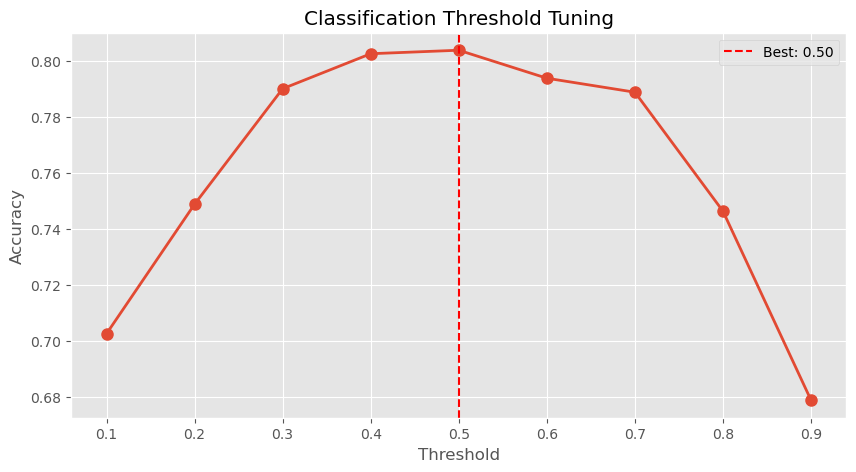

In [12]:
# Visualize threshold vs score
plt.figure(figsize=(10, 5))
plt.plot(thresholds, scores, 'o-', linewidth=2, markersize=8)
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Best: {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Classification Threshold Tuning')
plt.legend()
plt.grid(True)
plt.show()

## Summary

In this notebook, we learned **automated hyperparameter tuning** techniques that make model optimization more efficient:

### Key Concepts

1. **GridSearchCV**
   - Performs exhaustive search over all parameter combinations
   - Guarantees finding the best parameters within the grid
   - Best for small to moderate hyperparameter spaces
   - Use `n_jobs=-1` for parallel processing

2. **cross_validate**
   - Evaluates models using multiple metrics simultaneously
   - Provides comprehensive performance assessment
   - Returns both training and test scores
   - Useful for understanding different aspects of model performance

3. **RandomizedSearchCV**
   - Randomly samples parameter combinations
   - Much faster than GridSearchCV for large spaces
   - Good for initial exploration before fine-tuning
   - Accepts probability distributions for continuous parameters

4. **Threshold Tuning**
   - Classification thresholds can be optimized beyond the default 0.5
   - Use `TunedThresholdClassifierCV` for automated tuning (sklearn >= 1.5)
   - Manual tuning with `cross_val_predict` provides more control
   - Important for imbalanced datasets or specific business objectives

### Best Practices

✅ Start with `RandomizedSearchCV` for large hyperparameter spaces  
✅ Refine with `GridSearchCV` in a narrower range  
✅ Always use `return_train_score=True` to detect overfitting  
✅ Use `n_jobs=-1` to leverage all CPU cores  
✅ Evaluate with multiple metrics using `cross_validate`  
✅ Consider threshold tuning for classification problems  

### What's Next?

In the next notebook, we'll explore **regularization-specific cross-validation tools** like `RidgeCV`, `LassoCV`, and `ElasticNetCV`. These specialized methods are particularly efficient for tuning regularization strength (alpha) and connect directly back to the regularization techniques we studied in the **Regularization** chapter.